<a href="https://colab.research.google.com/github/beatrizmvtoledo11/house-prices-ml/blob/main/02_final_model_house_prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [89]:
"""
Projeto: House Prices Prediction (Kaggle)
Objetivo: Prever o preço de imóveis com base em características estruturais.
Autor: Beatriz Morales Vilha Toledo
"""

'\nProjeto: House Prices Prediction (Kaggle)\nObjetivo: Prever o preço de imóveis com base em características estruturais.\nAutor: Beatriz Morales Vilha Toledo\n'

In [90]:
# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Configuração visual
sns.set_style("whitegrid")


In [91]:
!mkdir -p src

In [92]:
%%writefile src/data.py
import pandas as pd
import numpy as np

def load_data(train_path, test_path, log_target=True):
    """
    Carrega datasets de treino e teste de imóveis.

    Parâmetros:
    - train_path: str, caminho do CSV de treino
    - test_path: str, caminho do CSV de teste
    - log_target: bool, aplica log1p no target SalePrice

    Retorna:
    - X_train_raw: DataFrame com features de treino
    - y: Series com target de treino (log transformado se log_target=True)
    - X_test_raw: DataFrame com features de teste
    """
    # Lê CSVs
    X_train_raw = pd.read_csv(train_path, index_col='Id')
    X_test_raw = pd.read_csv(test_path, index_col='Id')

    # Remove linhas sem SalePrice
    X_train_raw.dropna(axis=0, subset=['SalePrice'], inplace=True)

    # Separa target
    y = X_train_raw['SalePrice']
    if log_target:
        y = np.log1p(y)

    # Remove target do conjunto de features
    X_train_raw = X_train_raw.drop(['SalePrice'], axis=1)

    return X_train_raw, y, X_test_raw

def log_transform(y):
    """Aplica log1p no target"""
    return np.log1p(y)

def invert_log(y_log):
    """Reverte log1p"""
    return np.expm1(y_log)

def preprocess_data(X_train, X_valid, X_test):
    """
    Faz seleção de features, encoding e alinhamento
    """

    # FEATURE SELECTION
    low_cardinality_cols = [
        c for c in X_train.columns
        if X_train[c].nunique() < 10 and X_train[c].dtype == "object"
    ]

    numeric_cols = [
        c for c in X_train.columns
        if X_train[c].dtype in ['int64', 'float64']
    ]

    my_cols = low_cardinality_cols + numeric_cols

    # filtrar colunas
    X_train = X_train[my_cols].copy()
    X_valid = X_valid[my_cols].copy()
    X_test = X_test[my_cols].copy()

    # ONE-HOT ENCODING
    X_train = pd.get_dummies(X_train)
    X_valid = pd.get_dummies(X_valid)
    X_test = pd.get_dummies(X_test)

    # ALINHAR COLUNAS
    X_train, X_valid = X_train.align(X_valid, join='left', axis=1)
    X_train, X_test = X_train.align(X_test, join='left', axis=1)

    return X_train, X_valid, X_test

Overwriting src/data.py


In [93]:
# UPLOAD DE DADOS
from google.colab import drive
drive.mount('/content/drive')
train_path = "/content/drive/MyDrive/projeto_imoveis/train.csv"
test_path = "/content/drive/MyDrive/projeto_imoveis/test.csv"

from src.data import load_data

X_train_raw, y, X_test_raw = load_data(train_path, test_path, log_target=True)
print("Shape treino:", X_train_raw.shape)
print("Shape teste:", X_test_raw.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape treino: (1460, 79)
Shape teste: (1459, 79)


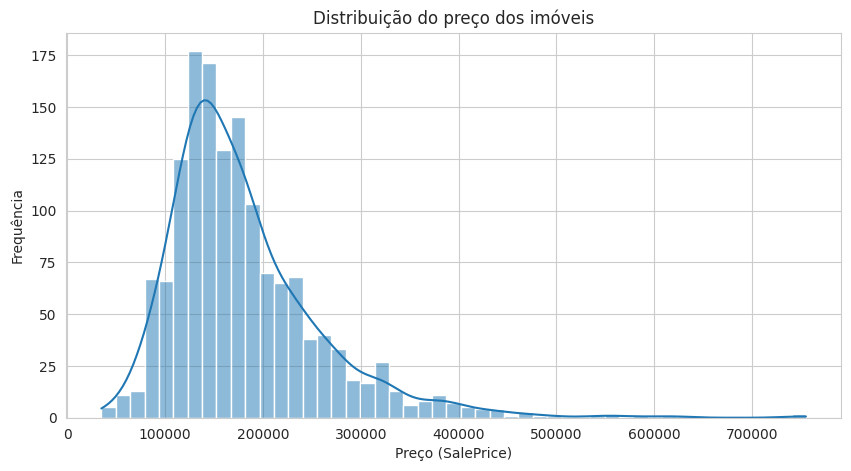

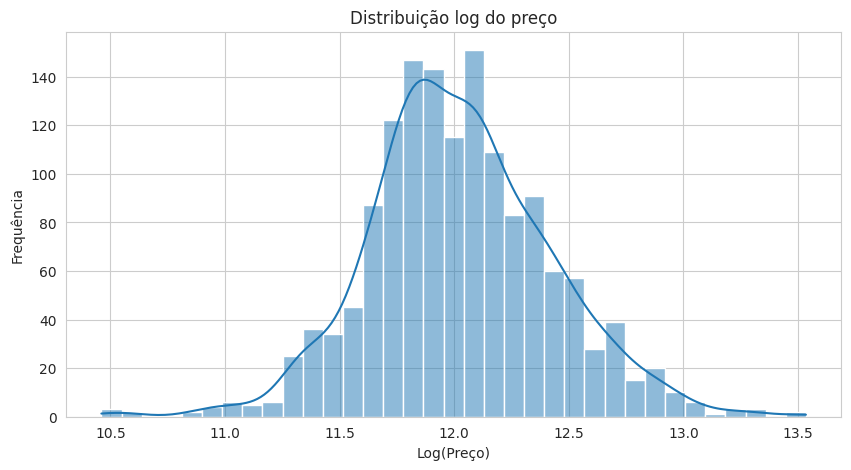

Top 10 variáveis mais correlacionadas com SalePrice:
OverallQual     0.817185
GrLivArea       0.700927
GarageCars      0.680625
GarageArea      0.650888
TotalBsmtSF     0.612134
1stFlrSF        0.596981
FullBath        0.594771
YearBuilt       0.586570
YearRemodAdd    0.565608
GarageYrBlt     0.541073
Name: SalePrice, dtype: float64


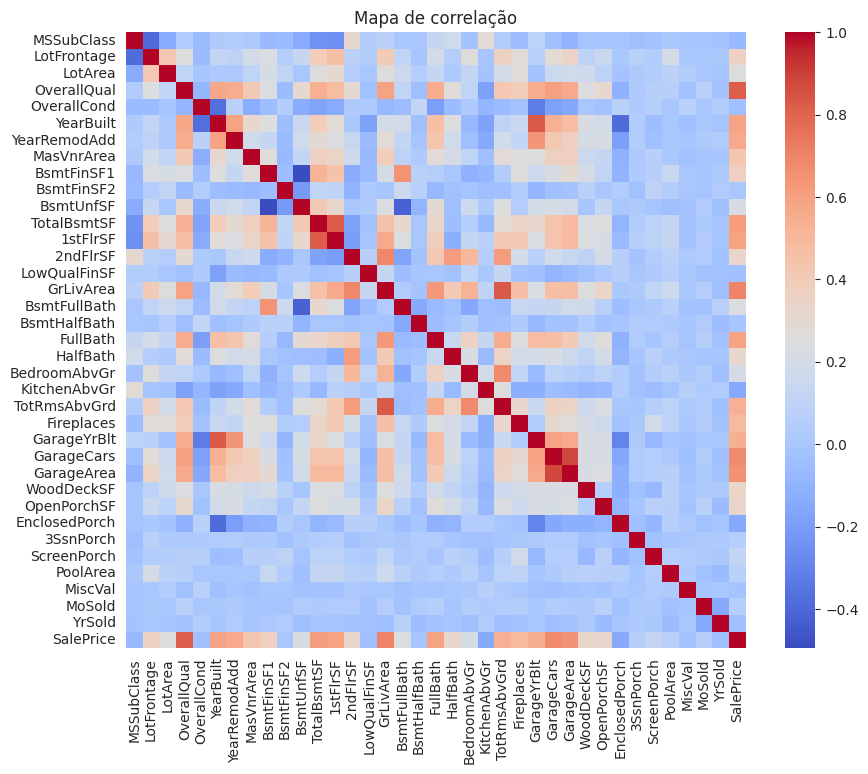

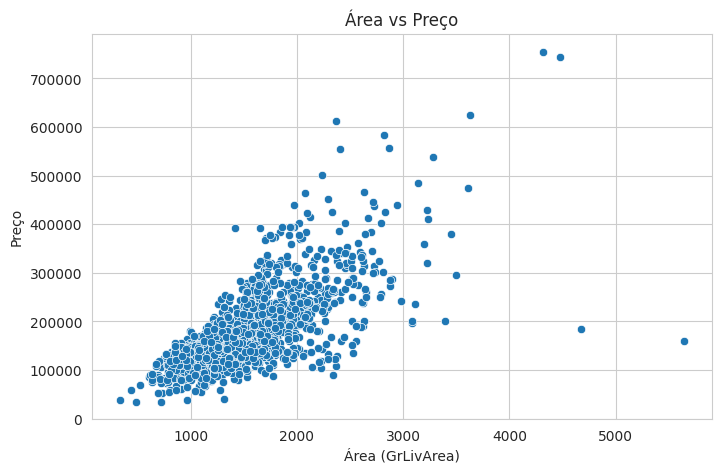

In [94]:
#ANÁLISE EXPLORATÓRIA (EDA)

# Preço original
plt.figure(figsize=(10,5))
sns.histplot(np.expm1(y), kde=True)
plt.title("Distribuição do preço dos imóveis")
plt.xlabel("Preço (SalePrice)")
plt.ylabel("Frequência")
plt.grid(True)
plt.show()

# Preço log
plt.figure(figsize=(10,5))
sns.histplot(y, kde=True)  # y já está log-transformado
plt.title("Distribuição log do preço")
plt.xlabel("Log(Preço)")
plt.ylabel("Frequência")
plt.grid(True)
plt.show()

# Correlação
df_corr = X_train_raw.copy()
df_corr['SalePrice'] = y
corr = df_corr.corr(numeric_only=True)

top_corr = corr['SalePrice'].sort_values(ascending=False)[1:11]
print("Top 10 variáveis mais correlacionadas com SalePrice:")
print(top_corr)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Mapa de correlação")
plt.show()

# Área vs Preço
plt.figure(figsize=(8,5))
sns.scatterplot(x=X_train_raw['GrLivArea'], y=np.expm1(y))
plt.title("Área vs Preço")
plt.xlabel("Área (GrLivArea)")
plt.ylabel("Preço")
plt.show()

In [95]:
#FEATURE ENGINEERING
from src.data import preprocess_data

X_train, X_valid, X_test = preprocess_data(
    X_train,
    X_valid,
    X_test_raw
)

print("Após encoding:")
print("Treino:", X_train.shape)
print("Validação:", X_valid.shape)
print("Teste:", X_test.shape)

Após encoding:
Treino: (1168, 36)
Validação: (292, 36)
Teste: (1459, 36)


Random Forest MAE: 0.09633752208081016
Random Forest MAE (valor real): 18348.85870089349


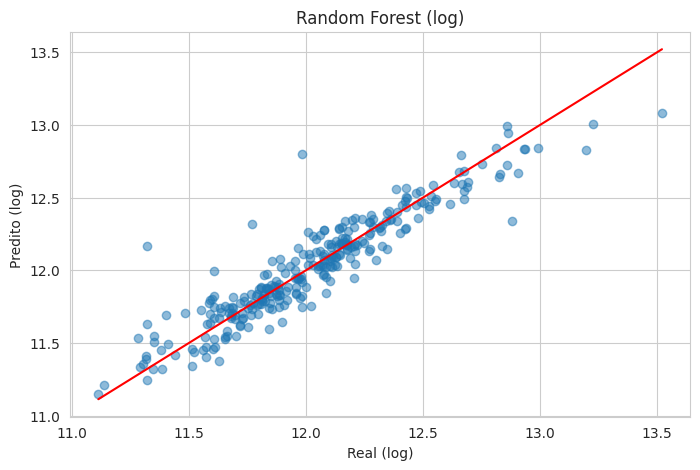

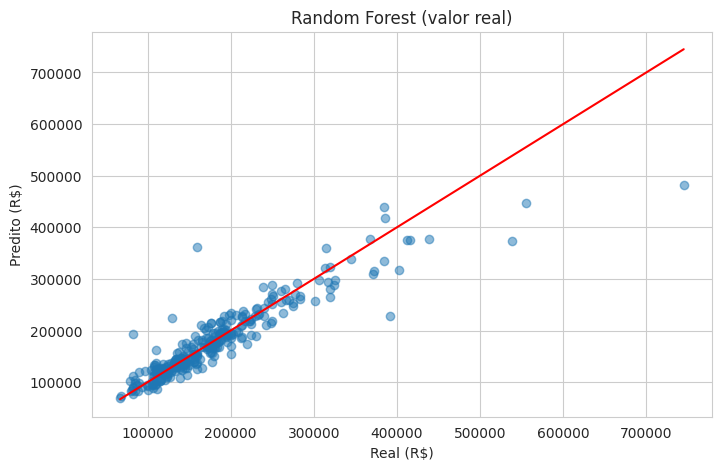

In [97]:
#RANDOM FOREST

from src.utils import invert_log

rf = RandomForestRegressor(random_state=0)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_valid)

# MAE em log
rf_mae = mean_absolute_error(rf_preds, y_valid)
print("Random Forest MAE:", rf_mae)

# converter para valor real
rf_preds_real = invert_log(rf_preds)
y_valid_real = invert_log(y_valid)

rf_mae_real = mean_absolute_error(rf_preds_real, y_valid_real)
print("Random Forest MAE (valor real):", rf_mae_real)

# GRÁFICO EM LOG
plt.figure(figsize=(8,5))
plt.scatter(y_valid, rf_preds, alpha=0.5)

plt.title("Random Forest (log)")
plt.xlabel("Real (log)")
plt.ylabel("Predito (log)")

plt.plot([y_valid.min(), y_valid.max()],
         [y_valid.min(), y_valid.max()],
         color='red')

plt.show()


# GRÁFICO EM VALOR REAL
plt.figure(figsize=(8,5))
plt.scatter(y_valid_real, rf_preds_real, alpha=0.5)

plt.title("Random Forest (valor real)")
plt.xlabel("Real (R$)")
plt.ylabel("Predito (R$)")

plt.plot([y_valid_real.min(), y_valid_real.max()],
         [y_valid_real.min(), y_valid_real.max()],
         color='red')

plt.show()

XGBoost MAE: 0.09254826099248702
XGBoost MAE (valor real): 17028.0812285959


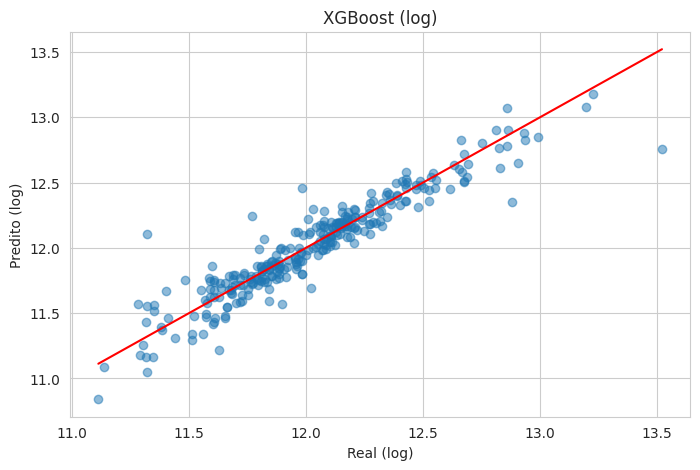

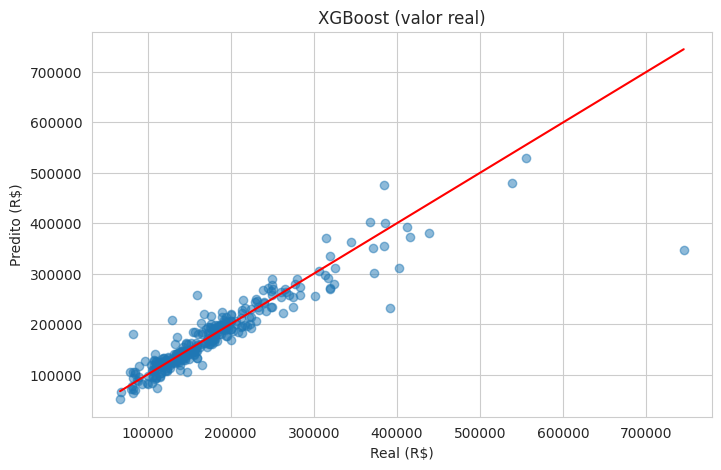

In [98]:
#XGBOOST

from src.utils import invert_log

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0
)

xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_valid)

# MAE em log
xgb_mae = mean_absolute_error(xgb_preds, y_valid)
print("XGBoost MAE:", xgb_mae)

# converter para valor real
xgb_preds_real = invert_log(xgb_preds)
y_valid_real = invert_log(y_valid)

xgb_mae_real = mean_absolute_error(xgb_preds_real, y_valid_real)
print("XGBoost MAE (valor real):", xgb_mae_real)

# GRÁFICO EM LOG
plt.figure(figsize=(8,5))
plt.scatter(y_valid, xgb_preds, alpha=0.5)

plt.title("XGBoost (log)")
plt.xlabel("Real (log)")
plt.ylabel("Predito (log)")

plt.plot([y_valid.min(), y_valid.max()],
         [y_valid.min(), y_valid.max()],
         color='red')

plt.show()


# GRÁFICO EM VALOR REAL
plt.figure(figsize=(8,5))
plt.scatter(y_valid_real, xgb_preds_real, alpha=0.5)

plt.title("XGBoost (valor real)")
plt.xlabel("Real (R$)")
plt.ylabel("Predito (R$)")

plt.plot([y_valid_real.min(), y_valid_real.max()],
         [y_valid_real.min(), y_valid_real.max()],
         color='red')

plt.show()

100 estimators MAE: 18630.873194028263
500 estimators MAE: 18410.567061750866
1000 estimators MAE: 18356.51466181508
Melhor: 1000


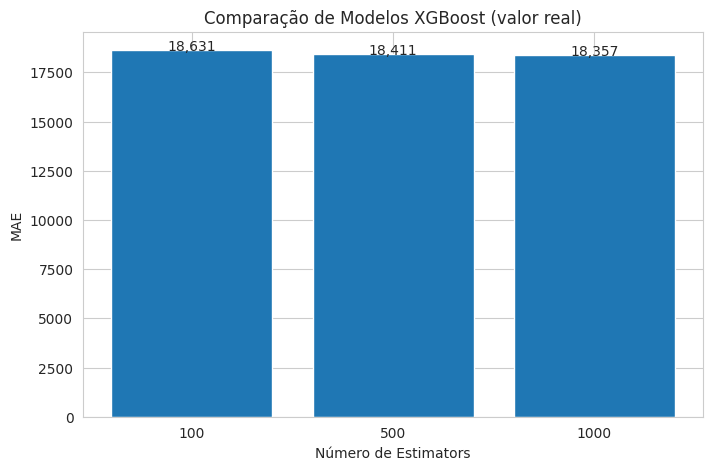

In [100]:
#EXPERIMENTAR
# EXPERIMENTAÇÃO XGBOOST

from src.utils import invert_log

models = {
    "100": XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=0),
    "500": XGBRegressor(n_estimators=500, learning_rate=0.05, random_state=0),
    "1000": XGBRegressor(n_estimators=1000, learning_rate=0.05, random_state=0)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    preds = model.predict(X_valid)

    # converter para valor real
    preds_real = invert_log(preds)
    y_valid_real = invert_log(y_valid)

    mae = mean_absolute_error(preds_real, y_valid_real)

    results[name] = mae
    print(f"{name} estimators MAE: {mae}")

# melhor modelo
best_model = min(results, key=results.get)
print("Melhor:", best_model)

# treinar modelo final
final_model = models[best_model]
final_model.fit(X_train, y_train)

# previsão no teste
preds_test = final_model.predict(X_test)
preds_test_real = invert_log(preds_test)

# gráfico
plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values())

plt.title("Comparação de Modelos XGBoost (valor real)")
plt.xlabel("Número de Estimators")
plt.ylabel("MAE")

for i, v in enumerate(results.values()):
    plt.text(i, v, f"{v:,.0f}", ha='center')

plt.show()

In [ ]:
#SUBMISSÃO
output = pd.DataFrame({
    'Id': X_test.index,
    'SalePrice': preds_test
})

output.to_csv('submission.csv', index=False)
print("Arquivo submission.csv gerado com sucesso!")